# **Human In The Loop In LangGraph**

In [1]:
from langchain_core.messages import HumanMessage;
from langchain_groq import ChatGroq;
from dotenv import load_dotenv;
from typing import TypedDict;

load_dotenv();

llm = ChatGroq(model="llama-3.3-70b-versatile");

class State(TypedDict):
    request: str;
    draft_action: str;
    human_approved: bool;
    result: str;

def plan_node(state: State) -> dict:

    resp = llm.invoke([HumanMessage(f"User wants: {state["request"]}. Write a one-sentence action plan.")]);

    print(f"[plan] Draft: {resp.content}");

    return {"draft_action": resp.content};


def execute_node(state: State) -> dict:

    if state["human_approved"]:

        return {"result": f"✅ EXECUTED: {state["draft_action"]}"};

    return {"result": "❌ REJECTED by human reviewer."};

In [ ]:
from langgraph.checkpoint.memory import MemorySaver;
from langgraph.graph import StateGraph, START, END;

builder = StateGraph(State);

builder.add_node("plan", plan_node);

builder.add_node("execute", execute_node);

builder.add_edge(START, "plan");

builder.add_edge("plan", "execute");

builder.add_edge("execute", END);

checkpointer = MemorySaver();

graph = builder.compile(
    checkpointer=checkpointer,
    interrupt_before=["execute"] # Interrupt (Put User Confirmation) Before Run Execute Fuction
);

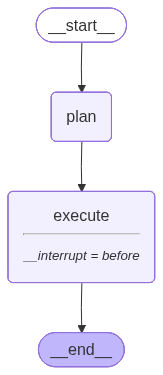

In [3]:
from IPython.display import Image, display;

display(Image(graph.get_graph().draw_mermaid_png()));

In [ ]:
cfg_ahmed = {"configurable": {"thread_id": "user_ahmed"}};

graph.invoke(
    {
        "request": "Send welcome email to ahmed@gmail.com",
        "draft_action": "",
        "human_approved": False,
        "result": ""
    },
    config=cfg_ahmed
);

snap = graph.get_state(cfg_ahmed);

print(f"⏸️ Paused before: {snap.next}");

print(f"state: {snap.values}");

human_input = input("Human Input: ").lower(); # Human Loop Input

human_input = True if human_input == "yes" else False;

graph.update_state(cfg_ahmed, {"human_approved": human_input});

final = graph.invoke(None, config=cfg_ahmed);

print(f"🏁 {final["result"]}, {final["human_approved"]}");

[plan] Draft: Compose and send a welcome email to ahmed@gmail.com with a personalized message and relevant introduction to the service or platform.
⏸️ Paused before: ('execute',)
   state: {'request': 'Send welcome email to ahmed@gmail.com', 'draft_action': 'Compose and send a welcome email to ahmed@gmail.com with a personalized message and relevant introduction to the service or platform.', 'human_approved': False, 'result': ''}
🏁 ❌ REJECTED by human reviewer., False
